# Fixing missing values for weather and consumption data

## Weather data
As shown in previous sections the weather data from metorological-raw is almost completely full. With only a few records missing in humidity, the practical and sufficient solution in this case is to drop the rows with missing values.

In [27]:
import pandas as pd

# Load the raw weather data
weather_path = '../../../data/paraguay/meteorological-raw.csv'
df_weather = pd.read_csv(weather_path)

In [28]:
df_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22445 entries, 0 to 22444
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     22445 non-null  object 
 1   temperature  22445 non-null  float64
 2   humidity     22364 non-null  float64
 3   wind_speed   22444 non-null  float64
 4   pressure     22441 non-null  float64
dtypes: float64(4), object(1)
memory usage: 876.9+ KB


In [29]:
# drop null rows
df_weather_cleaned = df_weather.dropna()
df_weather_cleaned.info()
print("\n")

# change in data set but getting biggest reduction in size
df_weather_reduction = df_weather.shape[0] - df_weather_cleaned.shape[0]
print(f"Rows removed: {df_weather_reduction}")
print(f"Percentage reduction: {df_weather_reduction / df_weather.shape[0] * 100:.2f}%")


<class 'pandas.core.frame.DataFrame'>
Index: 22359 entries, 0 to 22444
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     22359 non-null  object 
 1   temperature  22359 non-null  float64
 2   humidity     22359 non-null  float64
 3   wind_speed   22359 non-null  float64
 4   pressure     22359 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.0+ MB


Rows removed: 86
Percentage reduction: 0.38%


## Consumption data

Consumption data can not be handled at the same way because every feeder has missing values at different times meaning dropping values with greatly dicrease the information we have at a given timestamp. We want to have data for all feaders at one timestamp. As far as is possible.

As we can see in our exploration we have a few patterens emerging. When a substation feeder does not have data the others feeders within the same substain are more likely to not be on. We also mapped out some correlations across feeder substations and saw that some had a very high correlation. We could utilize this and interpolate the data from one feeder to the other, and vice versa, for the missing values. 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)


# use a list of tuples with pairs of feeders that are highly correlated to fill in missing values using each other's data
pivot_df = df_consumption.pivot_table(index='datetime', columns='feeder', values='consumption')
# Compute the correlation matrix between feeders
corr_matrix = pivot_df.corr()


high_corr_threshold = 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > high_corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
print(f"Highly correlated feeder pairs (correlation > {high_corr_threshold}):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.2f}")

Highly correlated feeder pairs (correlation > 0.8):
E1 and E4: 0.85
E1 and E7: 0.82
E2 and E4: 0.88
E2 and E7: 0.81
E2 and G1: 0.86
E4 and E7: 0.87
E6 and H5: 0.83
E7 and H3: 0.82
E7 and K1: 0.85
E7 and K2: 0.88


## Function for vizualising the feeder data

In [31]:
time_cols = [col for col in df_consumption.columns if 'time' in col.lower() or 'date' in col.lower()]
feeder_cols = [col for col in df_consumption.columns if col not in time_cols]

def show_missing_data(df):
    # Identify time and feeder columns

    if time_cols and 'feeder' in df.columns and 'consumption' in df.columns:
        time_col = time_cols[0]
        
        # Convert time column to datetime if not already
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        
        # Create pivot table with consumption values (not feeder names)
        presence = df.pivot(index=time_col, columns='feeder', values='consumption').notna()
        
        plt.figure(figsize=(20, 12))
        # Note: In this visualization, black = data present, white = data missing
        plt.imshow(presence.T, aspect='auto', interpolation='none', cmap='Greys')
        plt.xlabel('Date')
        plt.ylabel('Feeders')
        plt.title('Feeder Data Presence Over Time (white=Missing consumption data, black=Present)')
        
        # Set x-ticks to show dates
        xticks = np.linspace(0, len(presence.index) - 1, min(20, len(presence.index))).astype(int)
        plt.xticks(xticks, [presence.index[i].strftime('%Y-%m-%d') if not pd.isnull(presence.index[i]) else '' for i in xticks], rotation=45, ha='right', fontsize=10)
        plt.yticks(np.arange(len(presence.columns)), presence.columns, fontsize=10)
        plt.gca().set_yticks(np.arange(-0.5, len(presence.columns), 1), minor=True)
        plt.gca().yaxis.grid(True, which='minor', linestyle='-', linewidth=0.5)
        plt.colorbar(label='Data Present')
        plt.tight_layout()
        plt.show()
        
        # Print some statistics about missing data
        missing_stats = presence.mean().sort_values()
        print("\\nFeeder data availability (percentage of time periods with data):")
        for feeder in missing_stats.index[:10]:  # Show 10 worst feeders
            print(f"{feeder}: {missing_stats[feeder]*100:.1f}% available")
        
    else:
        print("Required columns not found for this plot.")


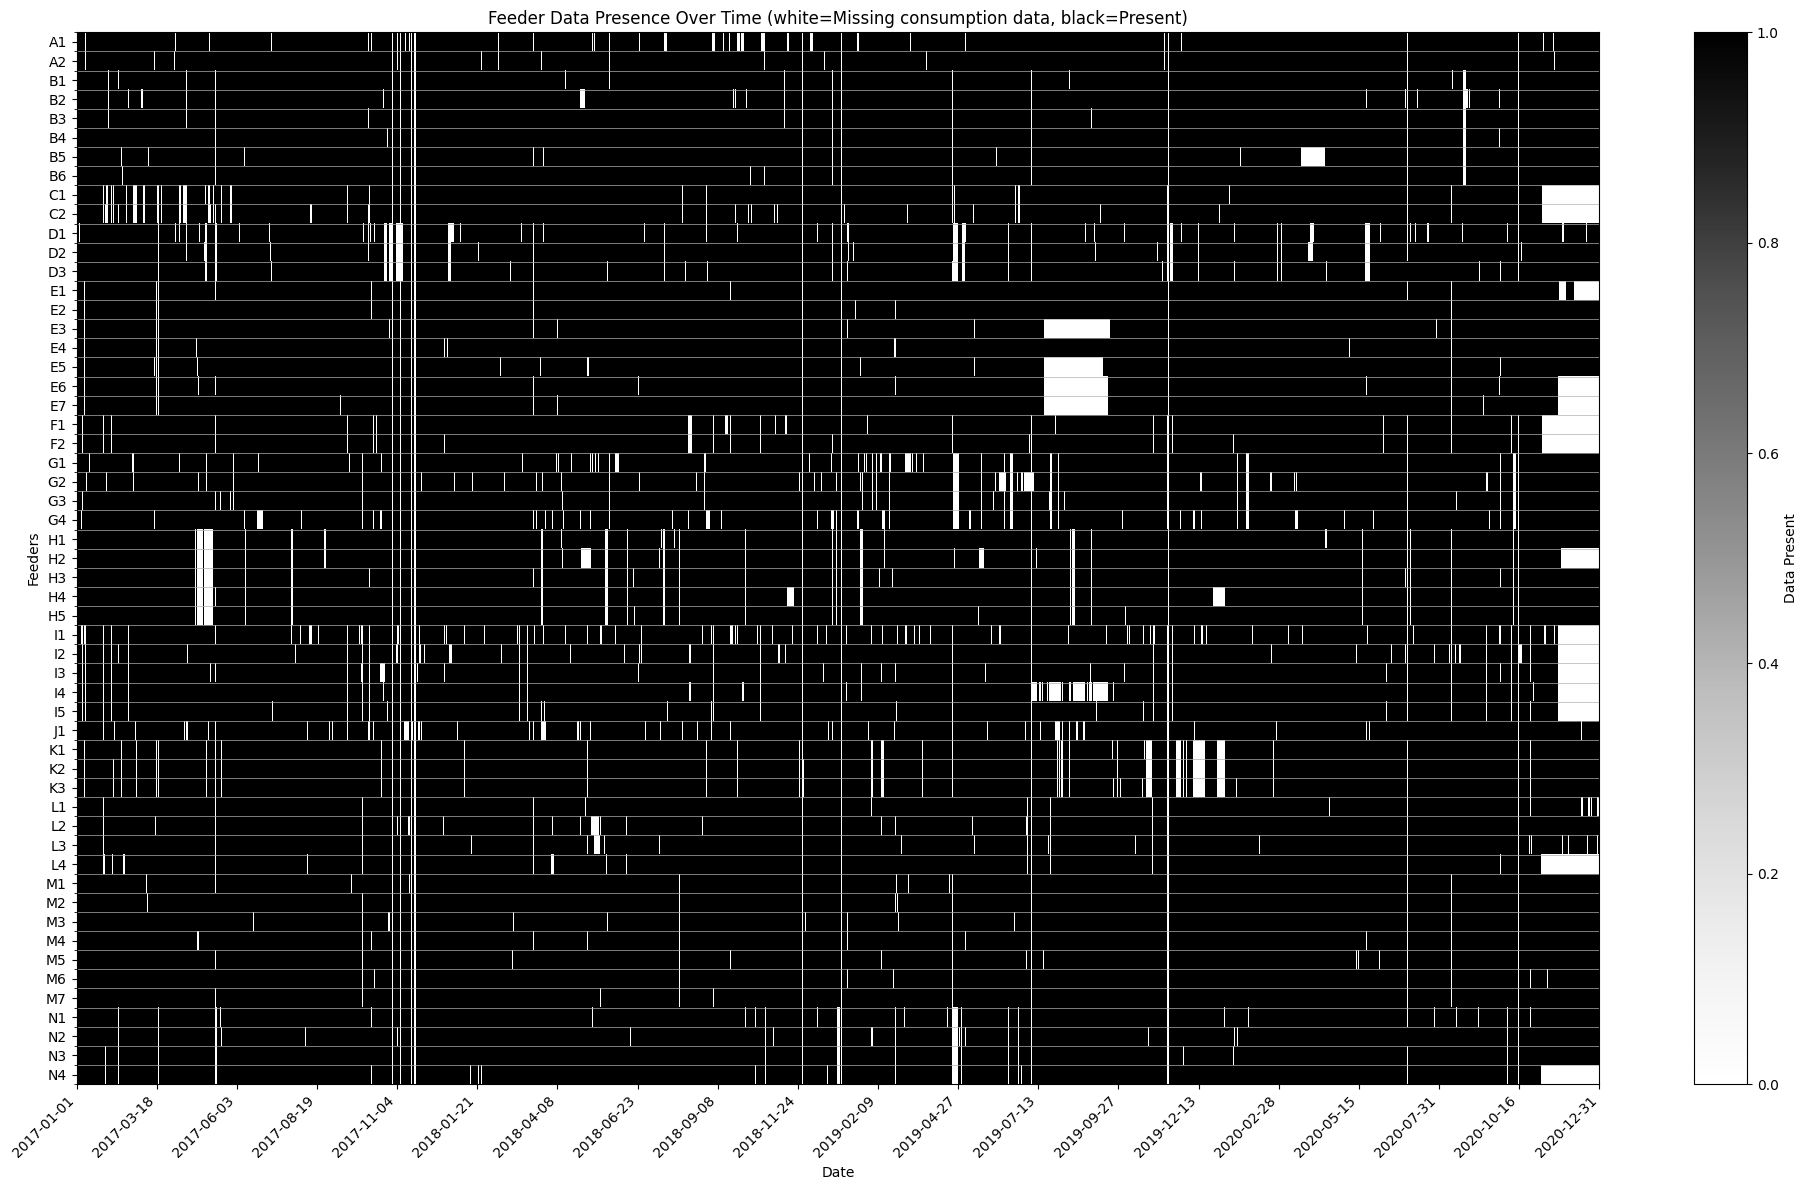

\nFeeder data availability (percentage of time periods with data):
I1: 91.0% available
I4: 91.6% available
E7: 91.8% available
E6: 91.9% available
C2: 92.0% available
H2: 92.5% available
C1: 93.0% available
N4: 93.5% available
I2: 93.7% available
D1: 93.8% available


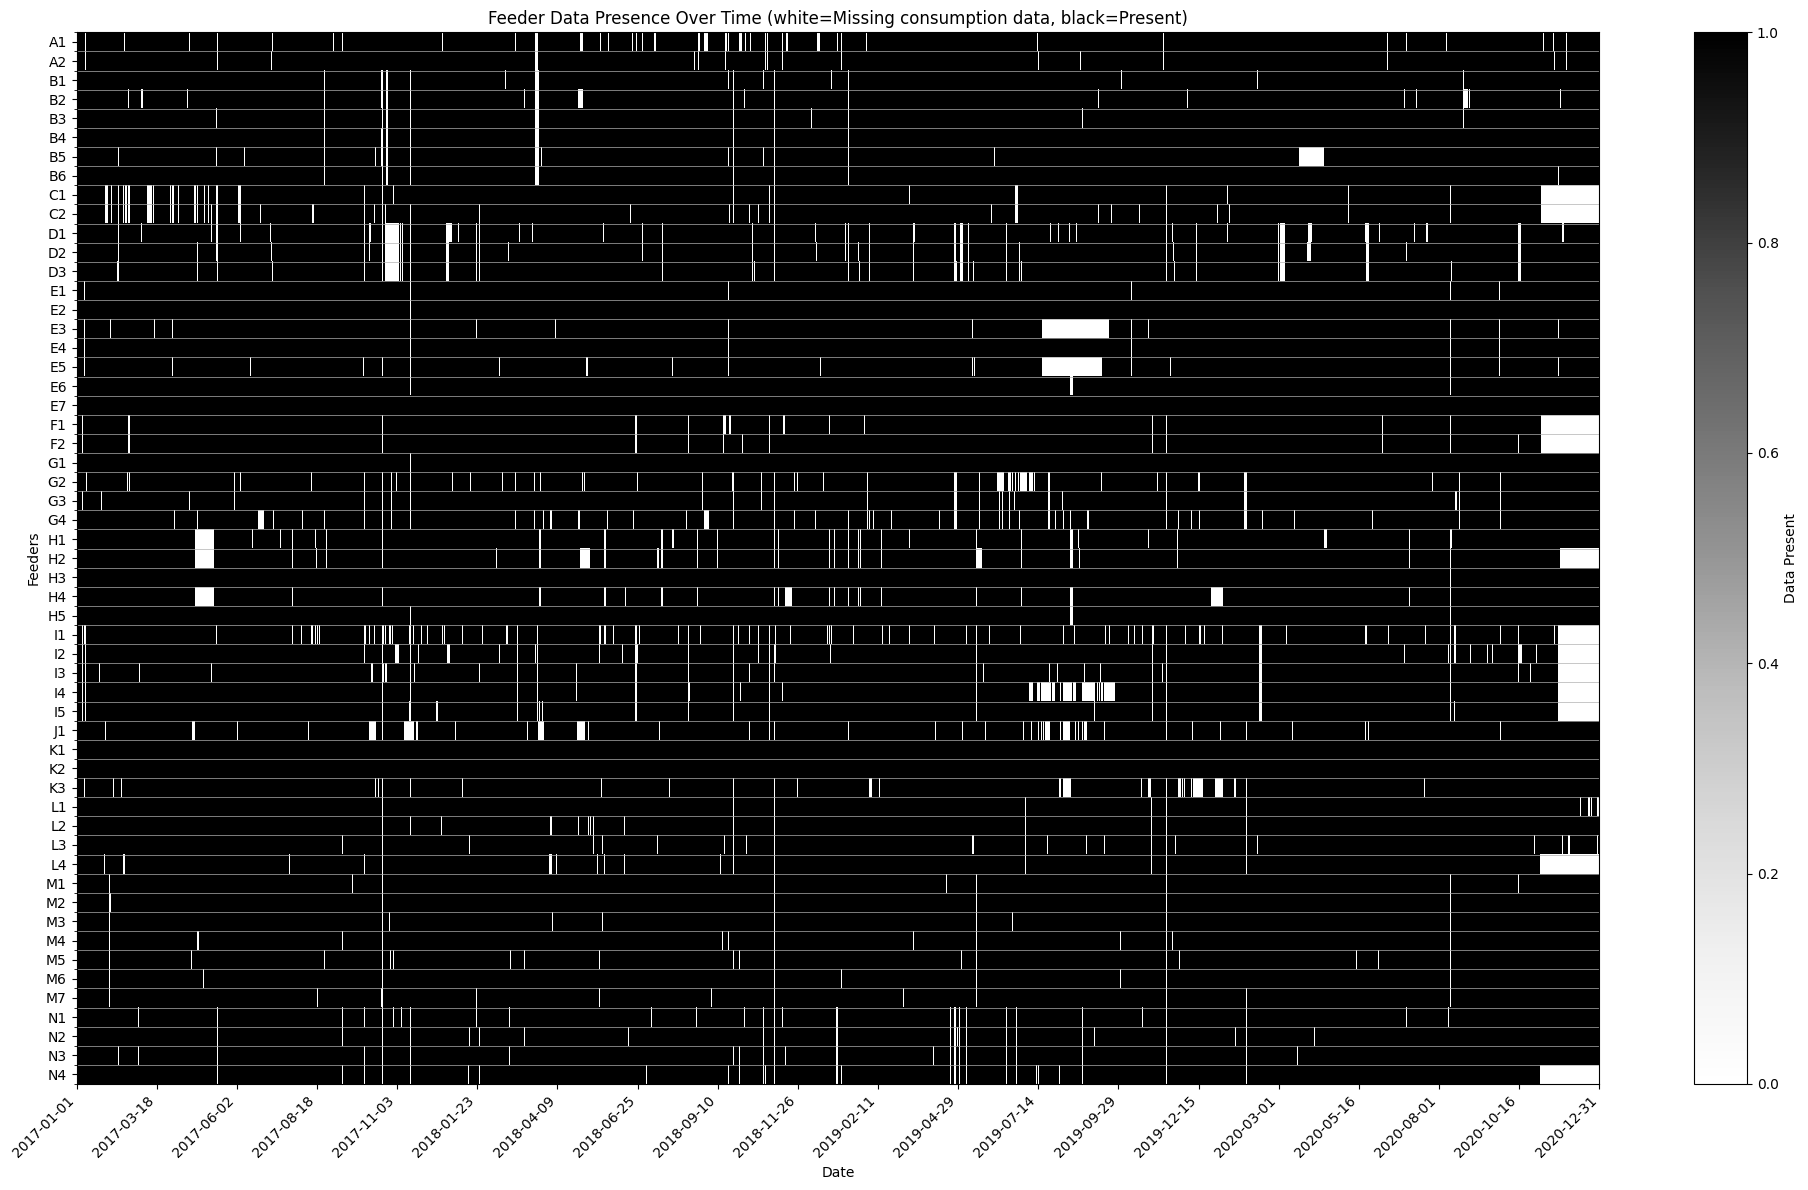

\nFeeder data availability (percentage of time periods with data):
I1: 91.4% available
I4: 92.0% available
C2: 92.5% available
H2: 93.0% available
C1: 93.5% available
N4: 94.0% available
I2: 94.1% available
D1: 94.3% available
J1: 94.4% available
F1: 94.6% available


In [32]:
show_missing_data(df_consumption)

# Use the pairs of highly correlated feeders to fill in missing values
for feeder1, feeder2, _ in high_corr_pairs:
    pivot_df[feeder1] = pivot_df[feeder1].fillna(pivot_df[feeder2])
    pivot_df[feeder2] = pivot_df[feeder2].fillna(pivot_df[feeder1])


# Convert back to original long format
df_consumption_filled = pivot_df.reset_index().melt(
    id_vars=['datetime'], 
    var_name='feeder', 
    value_name='consumption'
)

show_missing_data(df_consumption_filled)


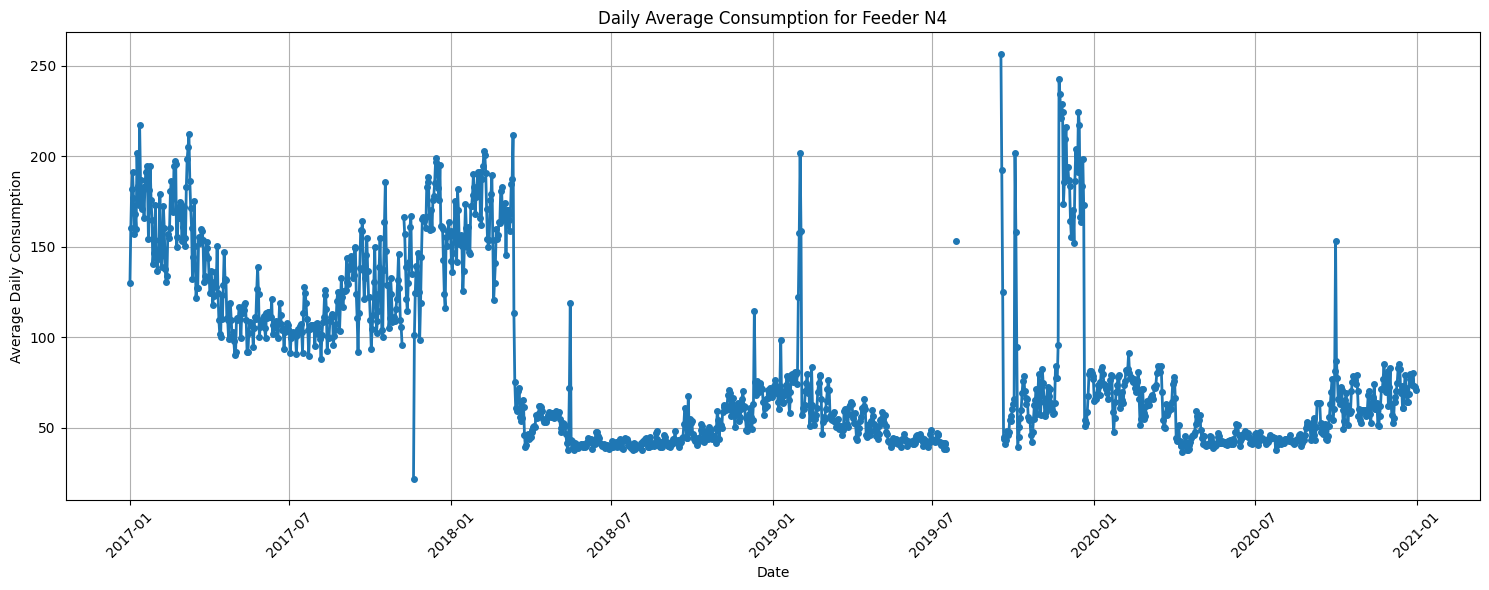

Daily averages from 2017-01 to 2020-12
Highest daily average: 256.60 in 2019-09-17
Lowest daily average: 21.70 in 2017-11-19


In [33]:
# look at monthly average consumption for N4 before 2021 to check for patterns

df_N4 = df_consumption_filled[df_consumption_filled['feeder'] == 'E3'].copy()
df_N4['datetime'] = pd.to_datetime(df_N4['datetime'], errors='coerce')
df_N4 = df_N4.set_index('datetime').sort_index()

# Resample to Daily averages
df_N4_daily = df_N4.resample('D')['consumption'].mean()

plt.figure(figsize=(15, 6))
plt.plot(df_N4_daily.index, df_N4_daily.values, marker='o', linestyle='-', markersize=4, linewidth=2)
plt.title('Daily Average Consumption for Feeder N4')
plt.xlabel('Date')
plt.ylabel('Average Daily Consumption')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print some statistics
print(f"Daily averages from {df_N4_daily.index.min().strftime('%Y-%m')} to {df_N4_daily.index.max().strftime('%Y-%m')}")
print(f"Highest daily average: {df_N4_daily.max():.2f} in {df_N4_daily.idxmax().strftime('%Y-%m-%d')}")
print(f"Lowest daily average: {df_N4_daily.min():.2f} in {df_N4_daily.idxmin().strftime('%Y-%m-%d')}")

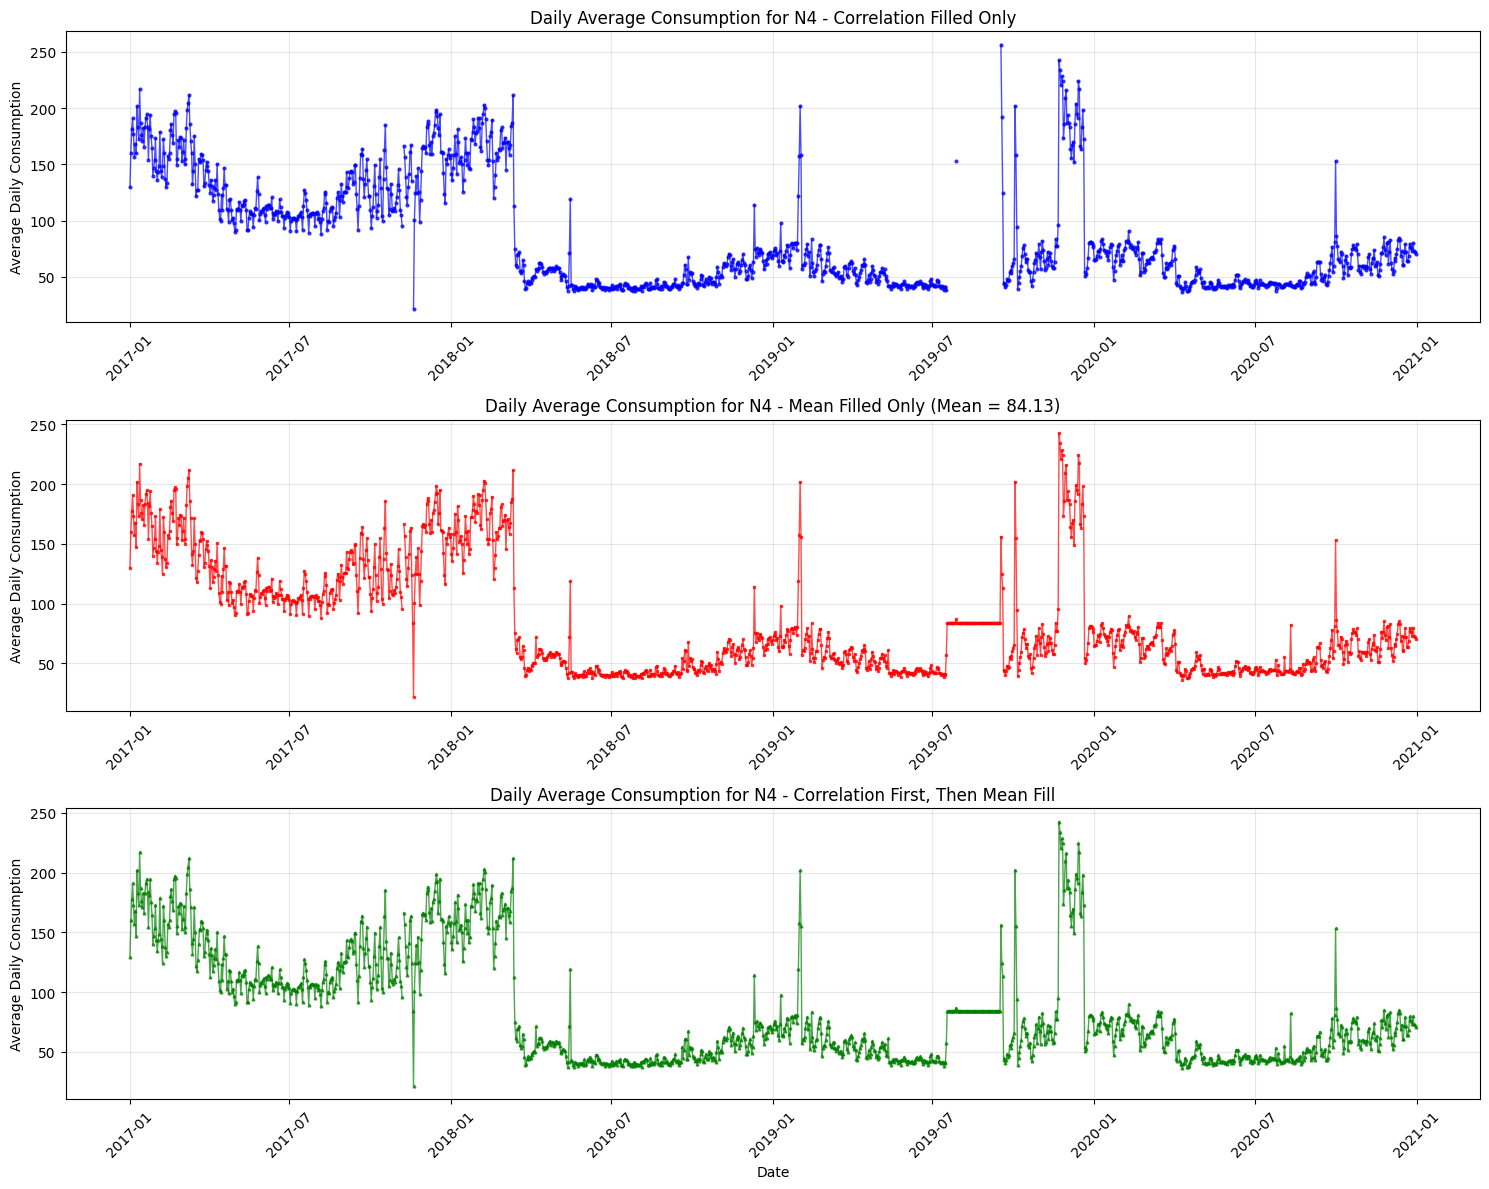

In [34]:
# Compare N4 consumption: correlation-filled, mean-filled, and both methods combined

# Get N4 data from correlation-filled dataset
df_N4_corr_filled = df_consumption_filled[df_consumption_filled['feeder'] == 'E3'].copy()
df_N4_corr_filled['datetime'] = pd.to_datetime(df_N4_corr_filled['datetime'], errors='coerce')
df_N4_corr_filled = df_N4_corr_filled.set_index('datetime').sort_index()
df_N4_corr_filled_before_2021 = df_N4_corr_filled[df_N4_corr_filled.index < '2021-01-01']

# Get N4 data and fill missing values with mean
df_N4_mean_filled = pivot_df['E3'].copy()
n4_mean = df_N4_mean_filled.mean()
df_N4_mean_filled = df_N4_mean_filled.fillna(n4_mean)
df_N4_mean_filled.index = pd.to_datetime(df_N4_mean_filled.index, errors='coerce')
df_N4_mean_filled_before_2021 = df_N4_mean_filled[df_N4_mean_filled.index < '2021-01-01']

# Get N4 data and apply both methods: first correlation, then mean for remaining missing values
df_N4_both_filled = pivot_df['E3'].copy()
# First apply correlation filling (this was already done in pivot_df)
# Then apply mean filling to any remaining missing values
df_N4_both_filled = df_N4_both_filled.fillna(n4_mean)
df_N4_both_filled.index = pd.to_datetime(df_N4_both_filled.index, errors='coerce')
df_N4_both_filled_before_2021 = df_N4_both_filled[df_N4_both_filled.index < '2021-01-01']

# Resample all three to daily averages
df_N4_corr_daily = df_N4_corr_filled_before_2021.resample('D')['consumption'].mean()
df_N4_mean_daily = df_N4_mean_filled_before_2021.resample('D').mean()
df_N4_both_daily = df_N4_both_filled_before_2021.resample('D').mean()

# Create three subplot comparison
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Correlation filled
axes[0].plot(df_N4_corr_daily.index, df_N4_corr_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, color='blue', alpha=0.7)
axes[0].set_title('Daily Average Consumption for N4 - Correlation Filled Only')
axes[0].set_ylabel('Average Daily Consumption')
axes[0].grid(True, alpha=0.3)

# Plot 2: Mean filled
axes[1].plot(df_N4_mean_daily.index, df_N4_mean_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, color='red', alpha=0.7)
axes[1].set_title(f'Daily Average Consumption for N4 - Mean Filled Only (Mean = {n4_mean:.2f})')
axes[1].set_ylabel('Average Daily Consumption')
axes[1].grid(True, alpha=0.3)

# Plot 3: Both methods combined
axes[2].plot(df_N4_both_daily.index, df_N4_both_daily.values, 
             marker='^', linestyle='-', markersize=2, linewidth=1, color='green', alpha=0.7)
axes[2].set_title('Daily Average Consumption for N4 - Correlation First, Then Mean Fill')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Daily Consumption')
axes[2].grid(True, alpha=0.3)

# Format all x-axis labels
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## When filling in the mean fails
As we can see in the plotting of the mean values has a few weakpoints. For larger blocks of missing information, filling in the mean hurts the value of the data, and especially looking at the difference between the last period we see a stark difference. We also belive the temporal dependencies can be utilized better for timeseries. Meaning we suggest to use the first available data both before and after a missing collection. To handle the large blocks were this is temporal distance is too far, lets say you have data from 1.oct and 31.oct which would leave to much room for error, we think leaving the value at 0 can indicate a empty data point our modelling technique should learn.

In [35]:
## Fill inn the gaps smaller than 5 days with mean from before and after

# Fill gaps smaller than 5 days with mean from before and after

def fill_small_gaps(series, max_gap_days):
    """
    Fill NaN gaps smaller than max_gap_days with the mean of surrounding values
    
    Parameters:
    series: pandas Series with datetime index (or string index convertible to datetime)
    max_gap_days: maximum gap size to fill (in days)
    
    Returns:
    pandas Series with small gaps filled
    """
    series_filled = series.copy()
    
    # Ensure index is datetime
    if not isinstance(series_filled.index, pd.DatetimeIndex):
        series_filled.index = pd.to_datetime(series_filled.index)
    
    # Find all NaN values
    nan_mask = series_filled.isna()
    
    if not nan_mask.any():
        return series_filled
    
    # Get start and end indices of consecutive NaN groups
    nan_groups = []
    start_idx = None
    
    for i, is_nan in enumerate(nan_mask):
        if is_nan and start_idx is None:
            start_idx = i
        elif not is_nan and start_idx is not None:
            nan_groups.append((start_idx, i-1))
            start_idx = None
    
    # Handle case where series ends with NaN
    if start_idx is not None:
        nan_groups.append((start_idx, len(series_filled)-1))
    
    # Fill small gaps
    for start_idx, end_idx in nan_groups:
        # Calculate gap duration in days
        start_date = series_filled.index[start_idx]
        end_date = series_filled.index[end_idx]
        gap_duration = (end_date - start_date).days + 1
        
        if gap_duration <= max_gap_days:
            # Get surrounding values for mean calculation
            before_value = None
            after_value = None
            
            # Get value before the gap
            if start_idx > 0:
                before_value = series_filled.iloc[start_idx - 1]
            
            # Get value after the gap
            if end_idx < len(series_filled) - 1:
                after_value = series_filled.iloc[end_idx + 1]
            
            # Calculate fill value
            if before_value is not None and after_value is not None:
                fill_value = (before_value + after_value) / 2
            elif before_value is not None:
                fill_value = before_value
            elif after_value is not None:
                fill_value = after_value
            else:
                continue  # Skip if no surrounding values
            
            # Fill the gap
            series_filled.iloc[start_idx:end_idx+1] = fill_value
            
            print(f"Filled gap from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')} "
                  f"({gap_duration} days) with value {fill_value:.2f}")
    
    return series_filled

# Apply to your consumption data


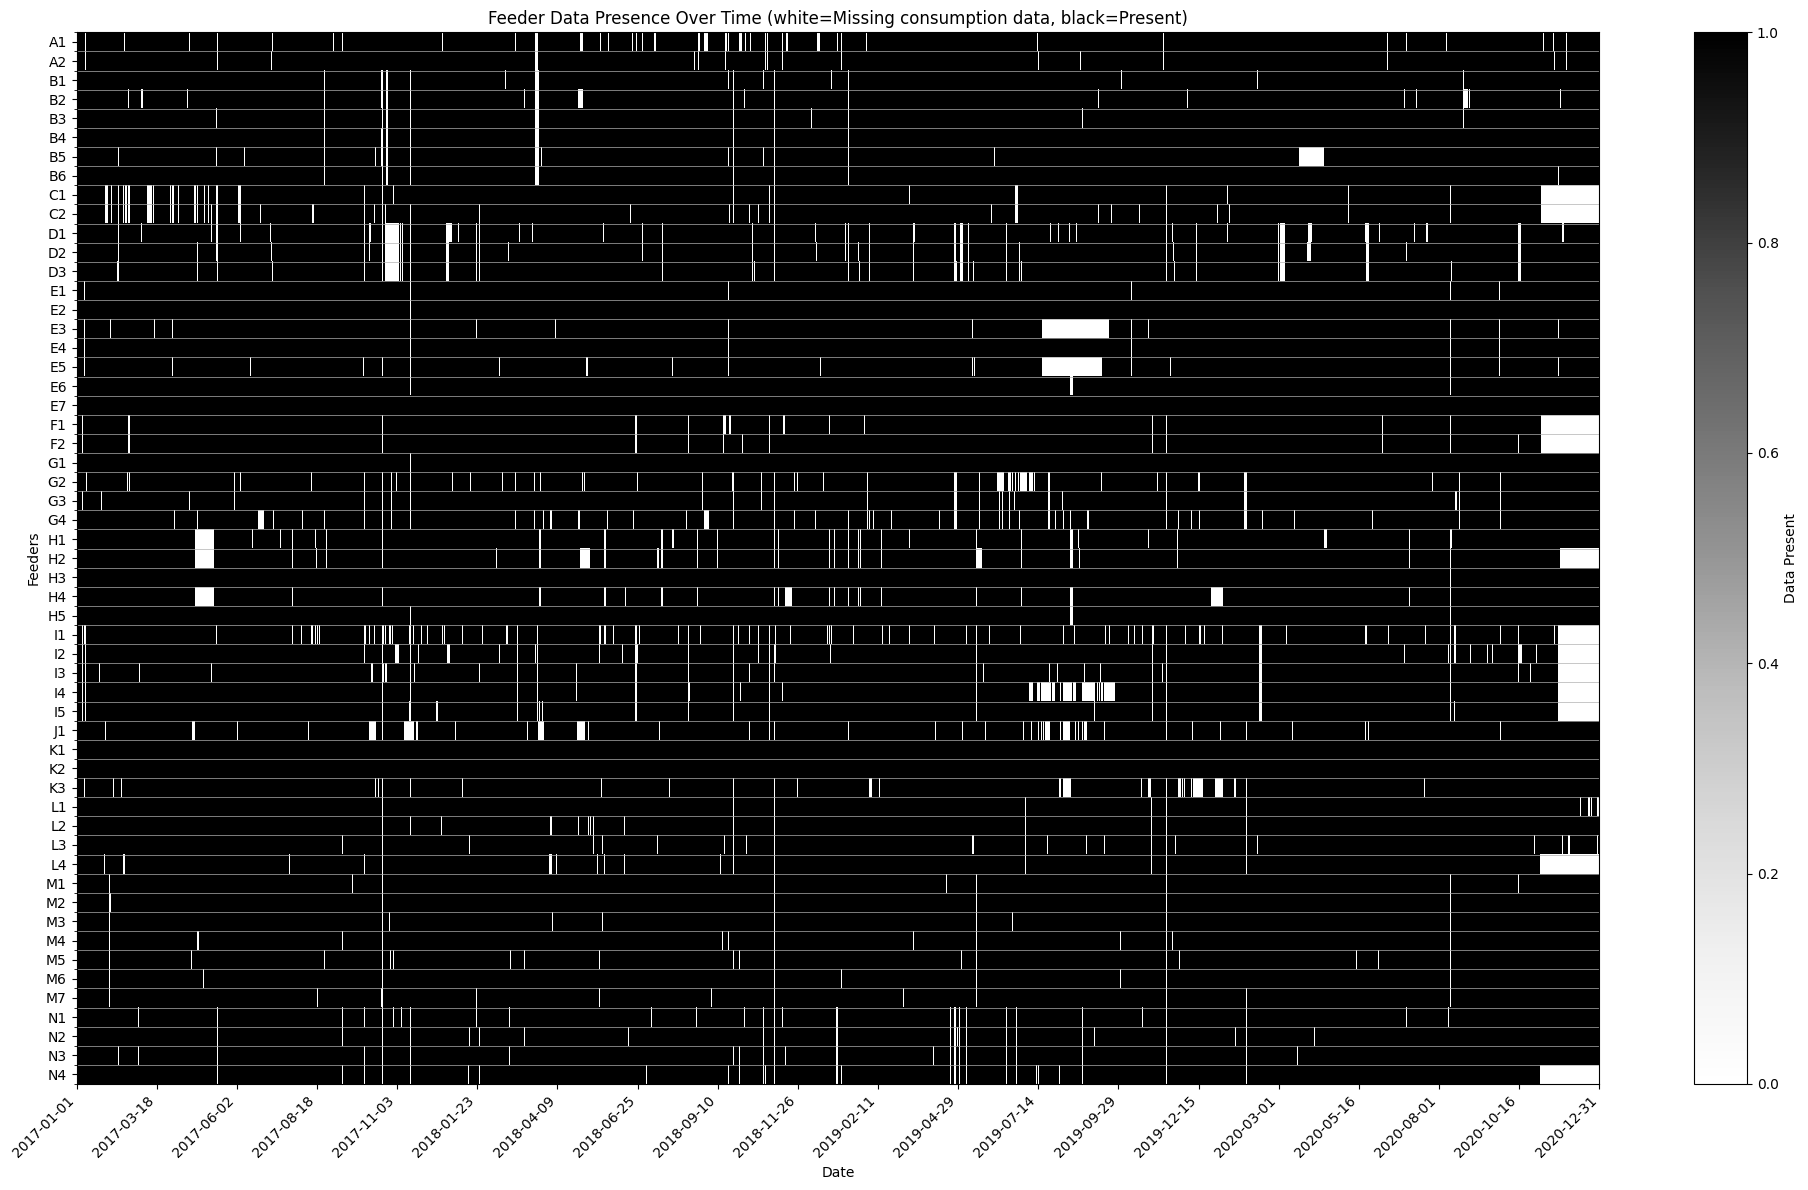

\nFeeder data availability (percentage of time periods with data):
I1: 91.4% available
I4: 92.0% available
C2: 92.5% available
H2: 93.0% available
C1: 93.5% available
N4: 94.0% available
I2: 94.1% available
D1: 94.3% available
J1: 94.4% available
F1: 94.6% available

Processing feeder: A1
Filled gap from 2017-01-09 to 2017-01-09 (1 days) with value 63.50
Filled gap from 2017-01-16 to 2017-01-16 (1 days) with value 47.50
Filled gap from 2017-01-19 to 2017-01-19 (1 days) with value 70.00
Filled gap from 2017-01-21 to 2017-01-21 (1 days) with value 43.50
Filled gap from 2017-01-22 to 2017-01-22 (1 days) with value 60.00
Filled gap from 2017-02-01 to 2017-02-01 (1 days) with value 55.00
Filled gap from 2017-02-09 to 2017-02-09 (1 days) with value 65.50
Filled gap from 2017-02-15 to 2017-02-15 (1 days) with value 99.00
Filled gap from 2017-02-17 to 2017-02-17 (1 days) with value 83.50
Filled gap from 2017-02-20 to 2017-02-20 (1 days) with value 58.50
Filled gap from 2017-03-12 to 2017-03-12

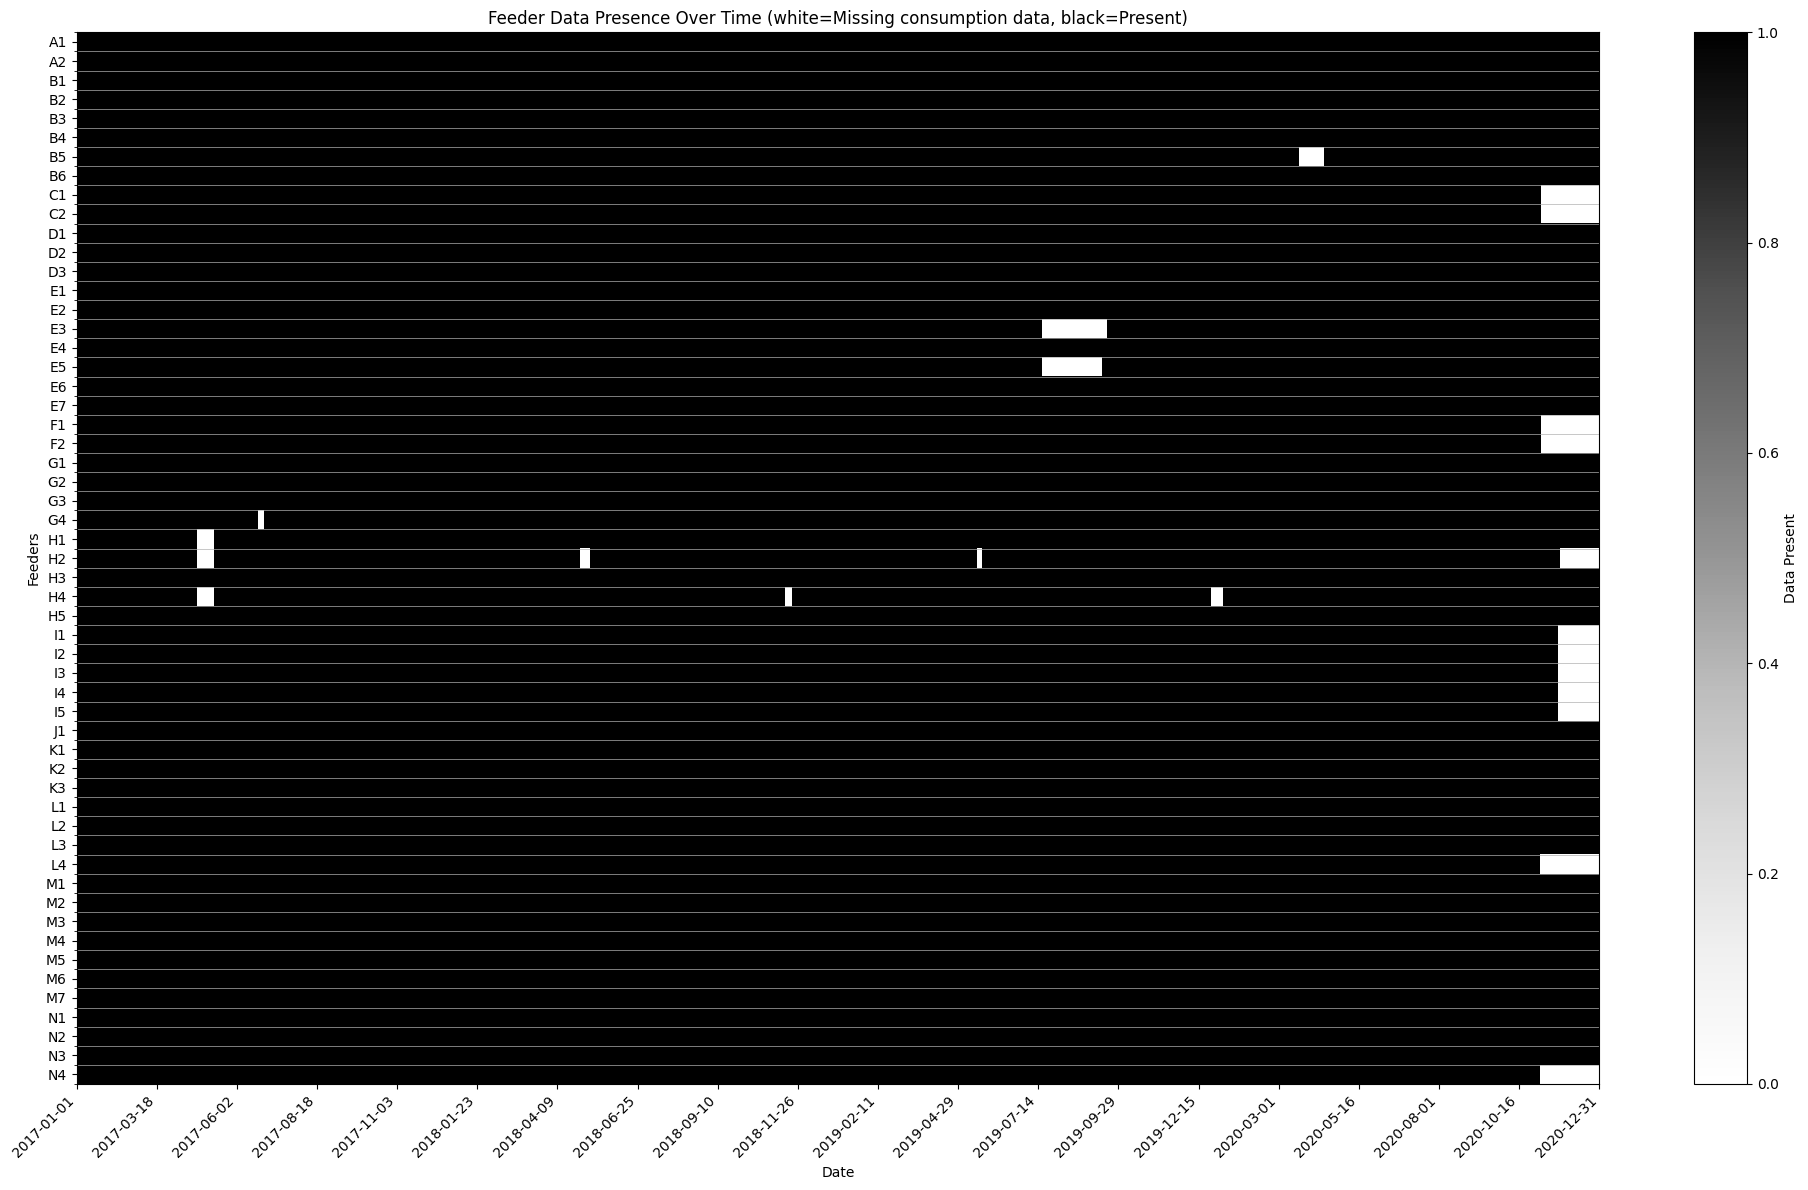

\nFeeder data availability (percentage of time periods with data):
H2: 95.3% available
E3: 95.8% available
E5: 96.1% available
L4: 96.1% available
N4: 96.1% available
F2: 96.1% available
F1: 96.1% available
C1: 96.1% available
C2: 96.1% available
I4: 97.2% available


In [36]:

show_missing_data(df_consumption_filled)


pivot_df_temporal_filled = pivot_df.copy()

for feeder in pivot_df_temporal_filled.columns:
    print(f"\nProcessing feeder: {feeder}")
    original_nan_count = pivot_df_temporal_filled[feeder].isna().sum()
    
    if original_nan_count > 0:
        pivot_df_temporal_filled[feeder] = fill_small_gaps(pivot_df_temporal_filled[feeder], max_gap_days=5)
        new_nan_count = pivot_df_temporal_filled[feeder].isna().sum()
        filled_count = original_nan_count - new_nan_count
        
        print(f"  Original NaN count: {original_nan_count}")
        print(f"  Filled: {filled_count}")
        print(f"  Remaining NaN: {new_nan_count}")
    else:
        print(f"  No missing values found")

print("\n" + "=" * 60)
print("Temporal gap filling completed!")

# Convert back to long format
df_consumption_temporal_filled = pivot_df_temporal_filled.reset_index().melt(
    id_vars=['datetime'], 
    var_name='feeder', 
    value_name='consumption'
)

show_missing_data(df_consumption_temporal_filled)


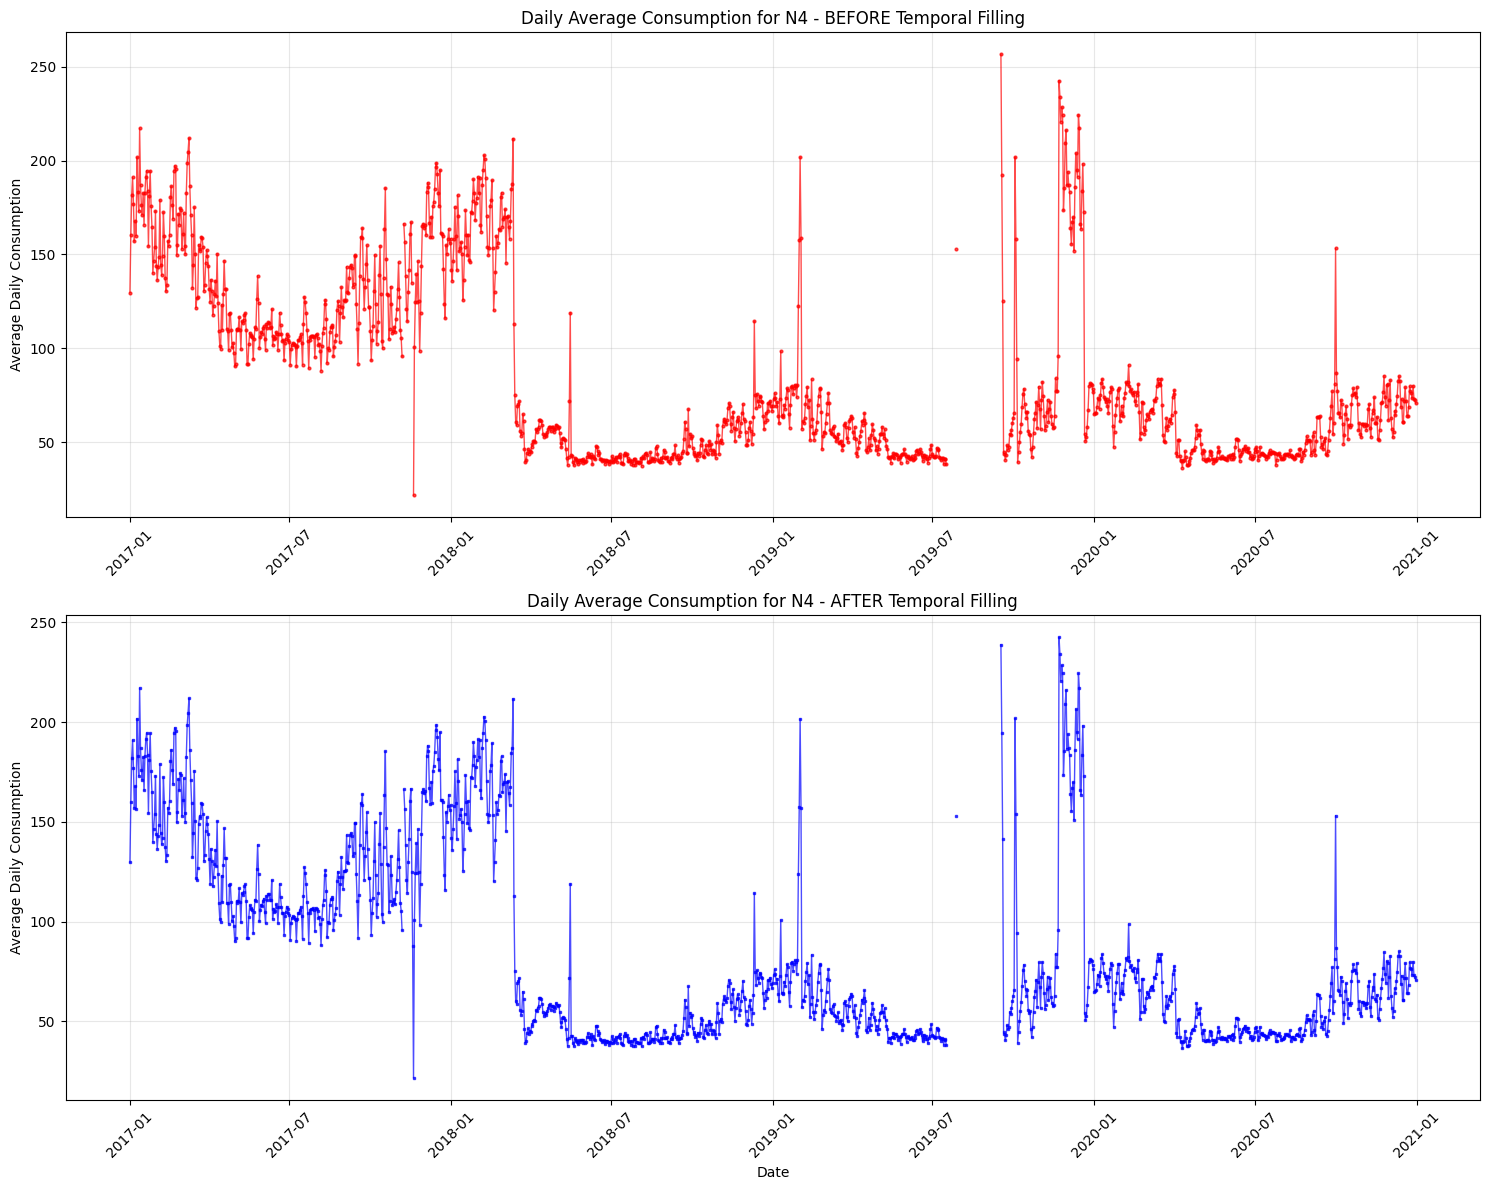

In [37]:
# Compare N4 consumption: before filling, after being filled - Two separate plots

# Get N4 data from temporal-filled dataset
df_N4_temporal_filled = df_consumption_temporal_filled[df_consumption_temporal_filled['feeder'] == 'E3'].copy()
df_N4_temporal_filled['datetime'] = pd.to_datetime(df_N4_temporal_filled['datetime'], errors='coerce')
df_N4_temporal_filled = df_N4_temporal_filled.set_index('datetime').sort_index()

# Get original N4 data (before any filling) for comparison
df_N4_original = pivot_df['E3'].copy()
df_N4_original.index = pd.to_datetime(df_N4_original.index, errors='coerce')

# Get temporal filled N4 data
df_N4_temporal_from_pivot = pivot_df_temporal_filled['E3'].copy()
df_N4_temporal_from_pivot.index = pd.to_datetime(df_N4_temporal_from_pivot.index, errors='coerce')
df_N4_temporal_from_pivot_before_2021 = df_N4_temporal_from_pivot[df_N4_temporal_from_pivot.index < '2021-01-01']

# Resample both to daily averages
df_N4_original_daily = df_N4_original.resample('D').mean()
df_N4_temporal_daily = df_N4_temporal_from_pivot_before_2021.resample('D').mean()

# Create two separate plots
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Before Temporal Filling
axes[0].plot(df_N4_original_daily.index, df_N4_original_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, 
             color='red', alpha=0.7)
axes[0].set_title('Daily Average Consumption for N4 - BEFORE Temporal Filling')
axes[0].set_ylabel('Average Daily Consumption')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: After Temporal Filling
axes[1].plot(df_N4_temporal_daily.index, df_N4_temporal_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, 
             color='blue', alpha=0.7)
axes[1].set_title('Daily Average Consumption for N4 - AFTER Temporal Filling')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Daily Consumption')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Filling remaining gaps with 0...
B5: Filled 565 remaining NaN values with 0
C1: Filled 1343 remaining NaN values with 0
C2: Filled 1343 remaining NaN values with 0
E3: Filled 1480 remaining NaN values with 0
E5: Filled 1367 remaining NaN values with 0
F1: Filled 1343 remaining NaN values with 0
F2: Filled 1343 remaining NaN values with 0
G4: Filled 142 remaining NaN values with 0
H1: Filled 379 remaining NaN values with 0
H2: Filled 1638 remaining NaN values with 0
H4: Filled 822 remaining NaN values with 0
I1: Filled 959 remaining NaN values with 0
I2: Filled 959 remaining NaN values with 0
I3: Filled 959 remaining NaN values with 0
I4: Filled 959 remaining NaN values with 0
I5: Filled 959 remaining NaN values with 0
L4: Filled 1367 remaining NaN values with 0
N4: Filled 1367 remaining NaN values with 0

Final data summary:
Total missing values after all filling: 0
Total data points: 1917465
Data completeness: 100.0%


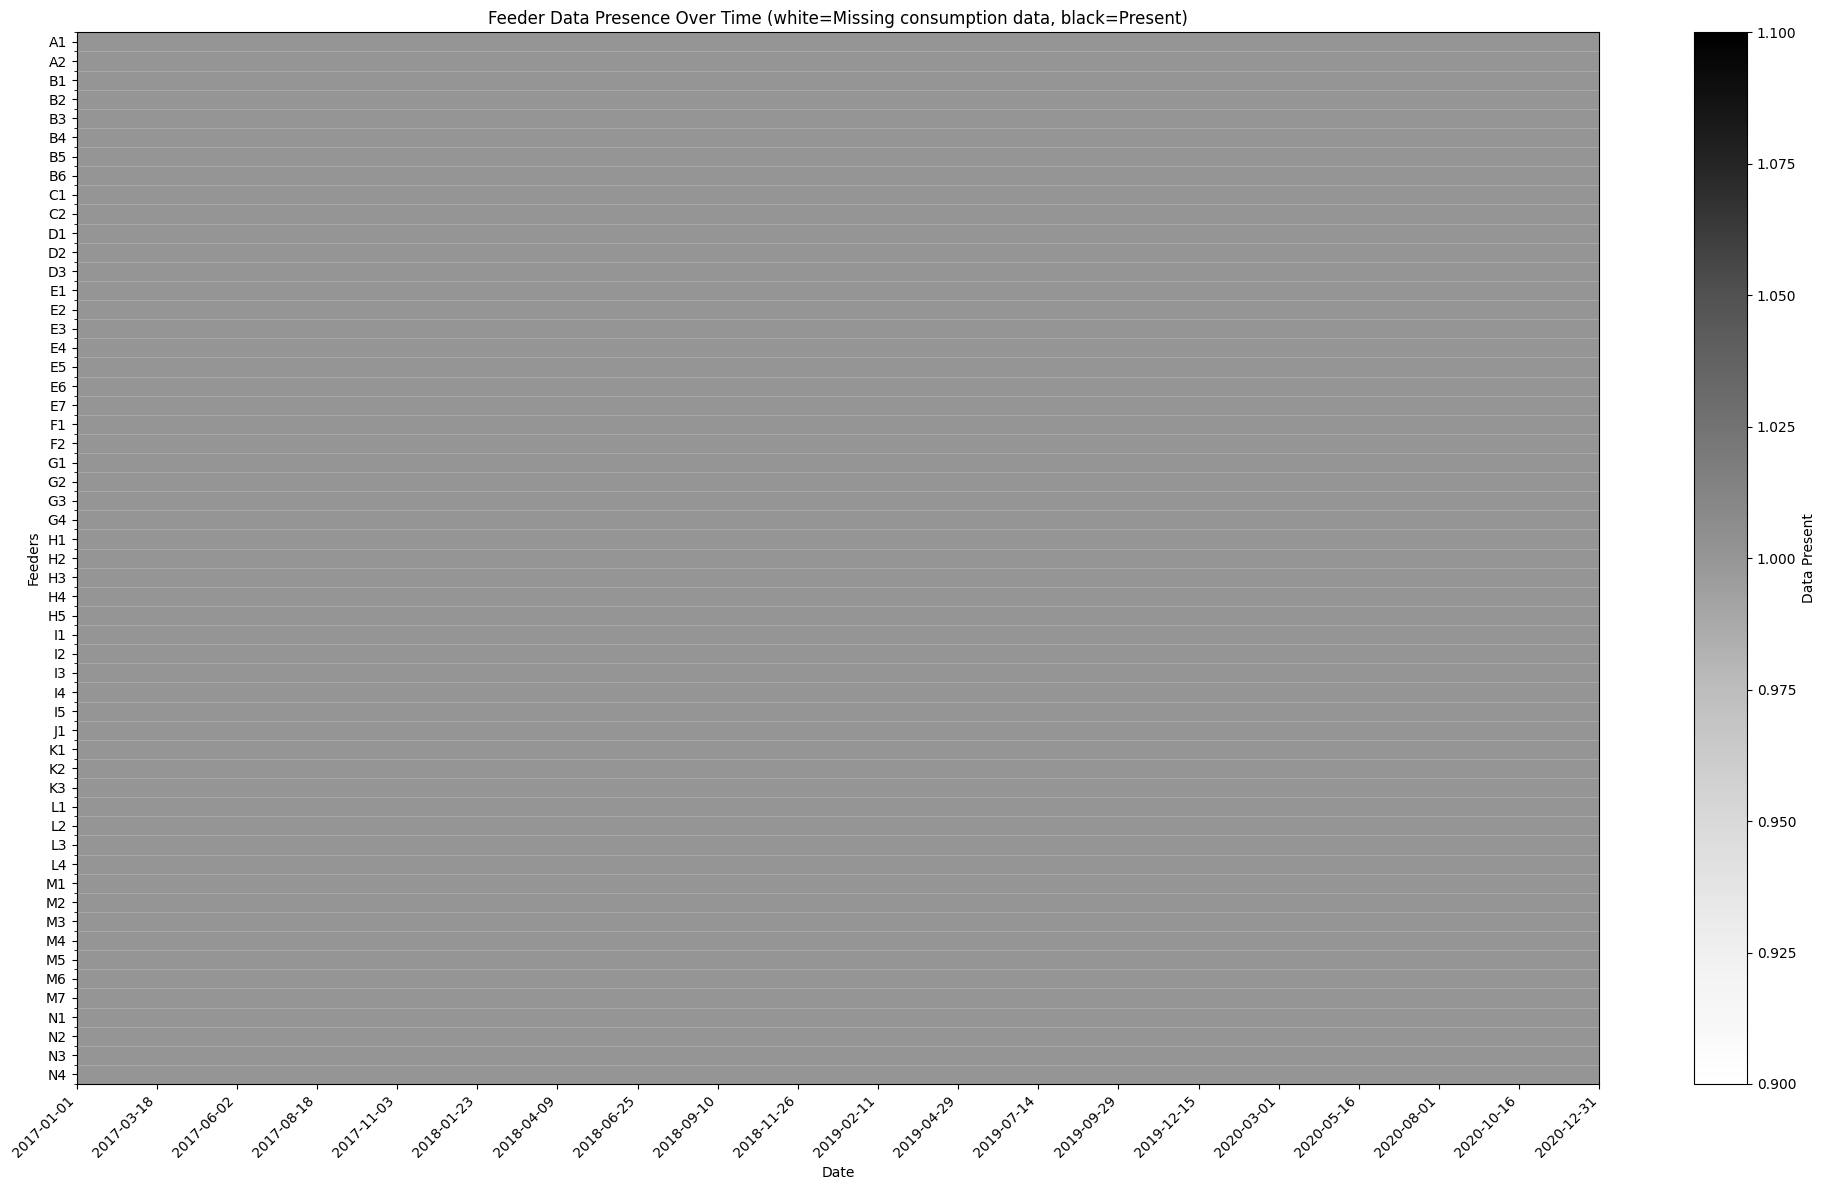

\nFeeder data availability (percentage of time periods with data):
A1: 100.0% available
A2: 100.0% available
B1: 100.0% available
B2: 100.0% available
B3: 100.0% available
B4: 100.0% available
B5: 100.0% available
B6: 100.0% available
C1: 100.0% available
C2: 100.0% available


In [38]:
# Fill the remaining gaps with 0

# Fill remaining NaN values with 0 for all feeders
pivot_df_final_filled = pivot_df_temporal_filled.copy()
pivot_df_final_filled = pivot_df_final_filled.fillna(0)

print("Filling remaining gaps with 0...")
print("=" * 50)

# Check how many values were filled with 0
for feeder in pivot_df_final_filled.columns:
    temporal_nan_count = pivot_df_temporal_filled[feeder].isna().sum()
    if temporal_nan_count > 0:
        print(f"{feeder}: Filled {temporal_nan_count} remaining NaN values with 0")

# Convert back to long format
df_consumption_final_filled = pivot_df_final_filled.reset_index().melt(
    id_vars=['datetime'], 
    var_name='feeder', 
    value_name='consumption'
)

print(f"\nFinal data summary:")
print(f"Total missing values after all filling: {pivot_df_final_filled.isna().sum().sum()}")
print(f"Total data points: {pivot_df_final_filled.size}")
print(f"Data completeness: {((pivot_df_final_filled.size - pivot_df_final_filled.isna().sum().sum()) / pivot_df_final_filled.size * 100):.1f}%")

# Show final missing data visualization
show_missing_data(df_consumption_final_filled)

## Showcase N4

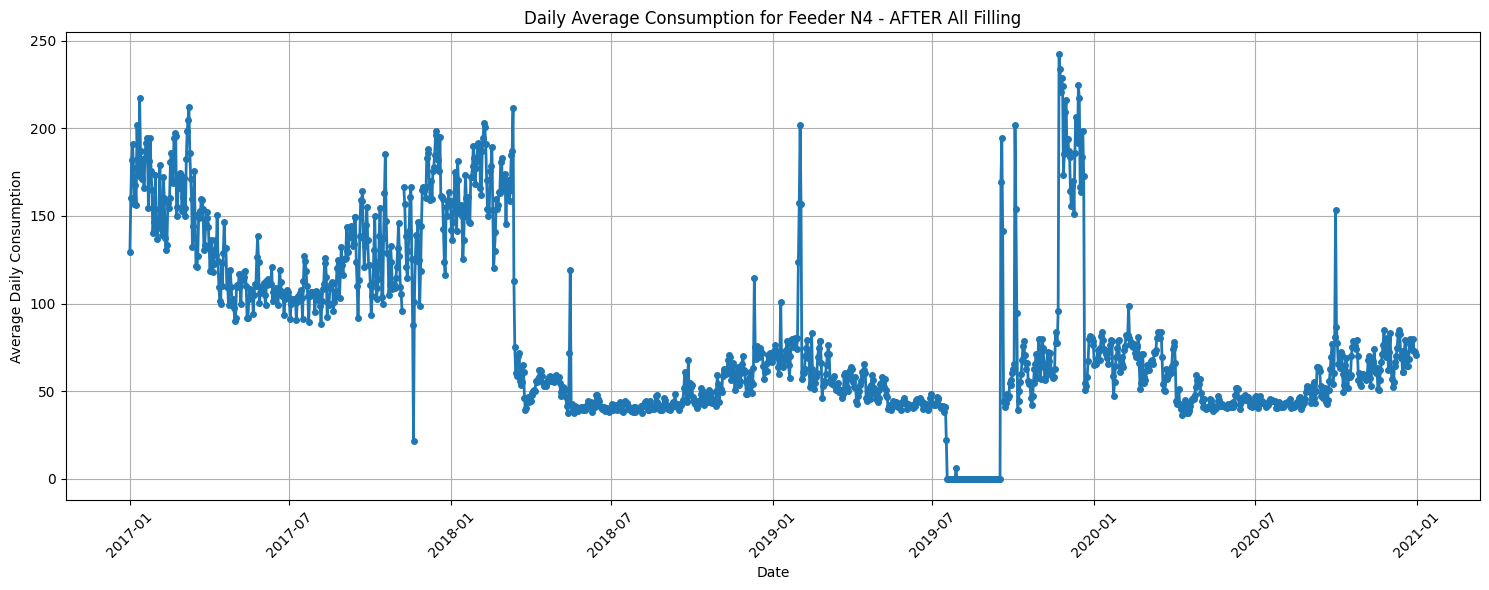

In [39]:
#print linechart of N4 consumption after all filling

df_consumption_final_filled['datetime'] = pd.to_datetime(df_consumption_final_filled['datetime'], errors='coerce')
df_consumption_final_filled = df_consumption_final_filled.set_index('datetime').sort_index()
df_N4_final_filled = df_consumption_final_filled[df_consumption_final_filled['feeder'] == 'E3'].copy()
df_N4_final_filled_daily = df_N4_final_filled.resample('D')['consumption'].mean()


plt.figure(figsize=(15, 6))
plt.plot(df_N4_final_filled_daily.index, df_N4_final_filled_daily.values, marker='o', linestyle='-', markersize=4, linewidth=2)
plt.title('Daily Average Consumption for Feeder N4 - AFTER All Filling')
plt.xlabel('Date')
plt.ylabel('Average Daily Consumption')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

